Date                   datetime64[ns]
Region                         object
Product_Category               object
Product_Name                   object
Service_Type                   object
Units_Sold                      int64
Product_Revenue_USD           float64
Service_Revenue_USD           float64
Total_Revenue_USD             float64
dtype: object
Date                   0
Region                 0
Product_Category       0
Product_Name           0
Service_Type           0
Units_Sold             0
Product_Revenue_USD    0
Service_Revenue_USD    0
Total_Revenue_USD      0
dtype: int64
0
0
0
93379.2875
265406.055
172026.7675
2
Revenue_Outlier_Flag
0    1824
1       2
Name: count, dtype: int64
        Date         Region Product_Category         Product_Name  \
0 2021-01-01           APAC       Pen Tablet       Wacom Intuos M   
1 2021-01-02           APAC    Mobile Studio  MobileStudio Pro 16   
2 2021-01-03  North America    Mobile Studio  MobileStudio Pro 13   
3 2021-01-04  North A

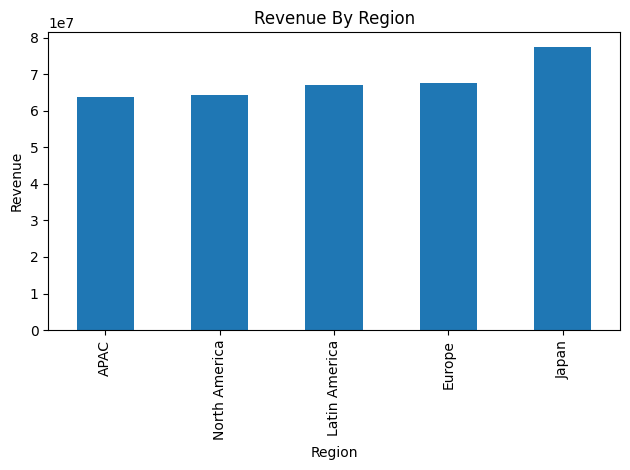

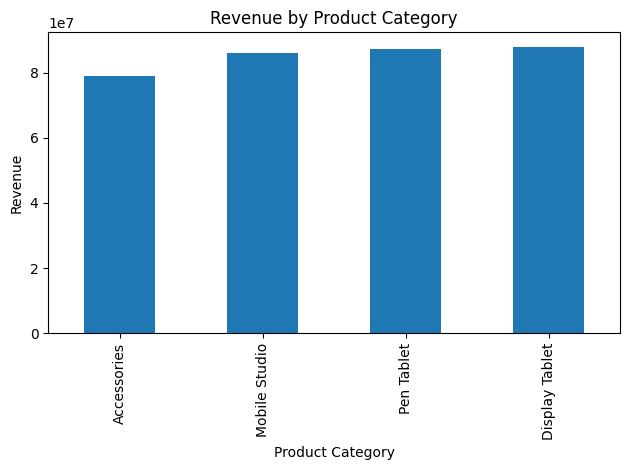

<Figure size 640x480 with 0 Axes>

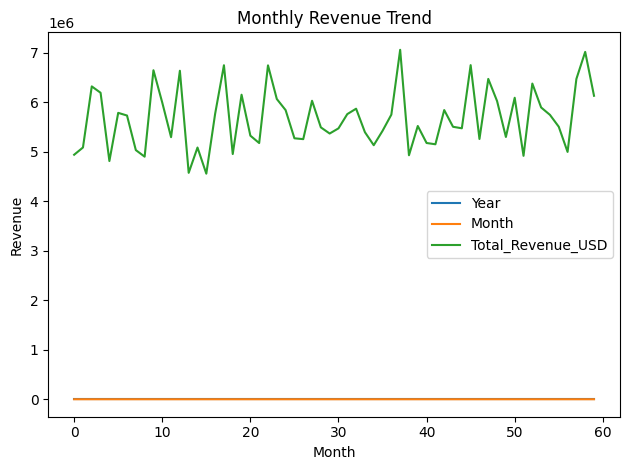

In [ ]:
# ========== Preprocessing Data ========== 
# Loading data
import pandas as pd

df = pd.read_csv("vgsales_new.csv")

print(df.shape)
print(df.head())

# Data type conversion
df["Name"] = df["Name"].str.strip()
df["Platform"] = df["Platform"].str.strip()
df["Genre"] = df["Genre"].str.strip()
df["Publisher"] = df["Publisher"].str.strip()

print(df.dtypes)

# Missing values
print(df.isnull().sum())

df["Year"] = df["Year"].fillna(df["Year"].median())
df["Publisher"] = df["Publisher"].fillna("Unknown")

print(df.isnull().sum())

df["Year"] = df["Year"].astype(int)

print(df.dtypes)

# Duplicates
print(df.duplicated().sum())
print(df.duplicated(subset=["Name", "Platform"]).sum())

df.drop_duplicates(subset=["Name", "Platform"], keep="first", inplace=True)

print(df.shape) 

# Outlier detection
Q1 = df["Global_Sales"].quantile(0.25)
Q3 = df["Global_Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(Q1)
print(Q3)
print(IQR)

outliers = df[(df["Global_Sales"] < lower_bound) |
              (df["Global_Sales"] > upper_bound)]

print(len(outliers))

df["Sales_Outlier_Flag"] = (
    (df["Global_Sales"] < lower_bound) | (df["Global_Sales"] > upper_bound)
).astype(int)

print(df["Sales_Outlier_Flag"].value_counts())

# Feature engineering
df["Sales_Gap"] = (df["NA_Sales"] - df["EU_Sales"])
df["JP_Share"] = ((df["JP_Sales"] / df["Global_Sales"]) * 100) .round(2)
df["Genre_Encoded"] = df["Genre"].astype("category").cat.codes
df["Platform_Encoded"] = df["Platform"].astype("category").cat.codes

print(df.head())

# Final validation
print(df.shape)
print(df.isnull().sum().sum())
df.to_csv("cleaned_vgsales.csv", index=False)

# ========== EDA ========== 
# Loading clead data and imports
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_wacom.csv", parse_dates=["Date"])
print(df.shape)

# Revenue by region bar chart
plt.figure()
region_revenue = df.groupby("Region")["Total_Revenue_USD"].sum().sort_values()
region_revenue.plot(kind="bar")
plt.title("Revenue By Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.tight_layout()

# Revenue by product category bar chart
plt.figure()
region_revenue = df.groupby("Product_Category")["Total_Revenue_USD"].sum().sort_values()
region_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.tight_layout()

# Monthly Revenue Trend line chart
plt.figure()
monthly_revenue = df.groupby(["Year", "Month"])["Total_Revenue_USD"].sum().reset_index()
monthly_revenue.plot(kind="line")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()